In [15]:
import sympy as sp
from sympy import *
# =====================================================================
# 1. DEFINE SYMBOLIC VARIABLES
# =====================================================================
# We define our coordinates, parameters, and their derivatives (dots)
r, M, b = sp.symbols('r M b', positive=True, real=True)
t_dot, r_dot, phi_dot = sp.symbols('t_dot r_dot phi_dot', real=True)
E, L = sp.symbols('E L', positive=True, real=True)
A = sp.symbols('A') #for kottler (cosmological constant)
b = sp.symbols('b')
v = sp.symbols('v')
dr_dphi = sp.symbols('dr_dphi')
lagrangian =sp.symbols('lagrangian')
r_dot_square = sp.symbols('r_dot_square')
dr_dphi_square = sp.symbols('dr_dphi_square')
Q = sp.symbols('Q', positive=True, real=True) #for reissner-nordstrom (charge)
g = sp.symbols('g') #for bardeen metric (the magnetic monopole charge)
l = sp.symbols('l') #for hayward (the fundamental length scale)
Ads = sp.symbols('Ads') #for sAds metric (the Ads curvature radius)
a = sp.symbols('a') #for kiselev metric (quintessence density)
w = sp.symbols('w') #for kiselev metric (equation of state)
y = sp.symbols('y') #for mannheim-kazanas (the conformal parameter)
k = sp.symbols('k') #for mannheim-kazanas (the conformal parameter)

# ---> CHANGE THIS TO TEST DIFFERENT METRICS <---
# Lapse function f(r) for Schwarzschild
f_r = 1 - (2 * M / r) - (a/r**(3*w+1))


# =====================================================================
# 2. DERIVE THE LAGRANGIAN 
# =====================================================================
# General metric form: ds^2 = -f(r)dt^2 + f(r)^(-1)dr^2 + r^2 d_phi^2
# (Assuming equatorial plane where theta = pi/2, so theta_dot = 0)
L_expr = 0.5 * (-f_r * t_dot**2 + (1/f_r) * r_dot**2 + r**2 * phi_dot**2)

print("--- 1. LAGRANGIAN (L) ---")
display(Eq(lagrangian,L_expr))
print_latex(Eq(lagrangian,L_expr))
print("\n")


# =====================================================================
# 3. DERIVE CONSTANTS OF MOTION (E and L)
# =====================================================================
# Find Time Momentum (Energy): p_t = dL/dt_dot = -E
p_t = sp.diff(L_expr, t_dot)
eq_E = sp.Eq(p_t, -E)
# Solve for t_dot
t_dot_sol = sp.solve(eq_E, t_dot)[0]

# Find Angular Momentum: p_phi = dL/dphi_dot = L
p_phi = sp.diff(L_expr, phi_dot)
eq_L = sp.Eq(p_phi, L)
# Solve for phi_dot
phi_dot_sol = sp.solve(eq_L, phi_dot)[0]

print("--- 2. CONSTANTS OF MOTION ---")
display(Eq(t_dot,t_dot_sol))
print_latex(Eq(t_dot,t_dot_sol))
print("\n")
display(Eq(phi_dot,phi_dot_sol))
print_latex(Eq(phi_dot,phi_dot_sol))
print("\n")


# =====================================================================
# 4. DERIVE RADIAL VELOCITY AND EFFECTIVE POTENTIAL
# =====================================================================
# Substitute t_dot and phi_dot back into the Lagrangian = 0
L_subbed = L_expr.subs({t_dot: t_dot_sol, phi_dot: phi_dot_sol})

# Isolate r_dot**2
eq_r_dot = sp.Eq(L_subbed * 2, 0) # Multiply by 2 to clear the 1/2
r_dot_squared_sol = sp.solve(eq_r_dot, r_dot**2)[0]

print("--- 3. RADIAL VELOCITY (r_dot^2) ---")
display(Eq(r_dot_square,r_dot_squared_sol))
print_latex(Eq(r_dot_square,r_dot_squared_sol))
print("\n")

# For photon trajectories parameterized by impact parameter b, 
# the effective potential is structurally defined as f(r) / r^2
V_r = f_r / r**2

print("--- 4. EFFECTIVE POTENTIAL V(r) ---")
display(Eq(v,V_r))
print_latex(Eq(v,V_r))
print("\n")


# =====================================================================
# 5. FIND THE PHOTON SPHERE AND CRITICAL IMPACT PARAMETER
# =====================================================================
# Set dV/dr = 0 and solve for r
dV_dr = sp.diff(V_r, r)
r_ph_solutions = sp.solve(dV_dr, r)

# Get the valid real root (often the first or only one for simple metrics)
r_ph = r_ph_solutions[0]

# Calculate max potential and critical impact parameter
V_max = V_r.subs(r, r_ph)
b_crit = 1 / sp.sqrt(V_max)
b_critical = sp.simplify(b_crit)
print("--- 5. OPTICAL BOUNDARIES ---")
print(f"Photon Sphere radius (r_ph): {r_ph}") 
display(Eq(r,r_ph))
print_latex(Eq(r,r_ph))
print("\n")
print(f"Critical Impact Parameter (b_crit): {b_critical}") 
display(Eq(b,b_critical))
print_latex(Eq(b,b_critical))
print("\n")


# =====================================================================
# 6. DERIVE THE ORBITAL EQUATION (dr/dphi)^2 AND dr/dphi
# =====================================================================
# Chain rule: (dr/dphi)^2 = (r_dot)^2 / (phi_dot)^2
dr_dphi_squared = r_dot_squared_sol / (phi_dot_sol**2)

# Substitute Energy with Impact Parameter: E**2 = (L/b)**2
dr_dphi_squared_b = dr_dphi_squared.subs(E**2, (L/b)**2)

# Simplify to get the final geometric shape equation
dr_dphi_squared_final = sp.simplify(dr_dphi_squared_b)

# Take the square root to get the actual 1st-order ODE for your solver
dr_dphi_final = sp.sqrt(dr_dphi_squared_final)

print("--- 6. ORBITAL EQUATION (dr/dphi)^2 ---")
display(Eq(dr_dphi_square,dr_dphi_squared_final))
print_latex(Eq(dr_dphi_square,dr_dphi_squared_final))
print("\n")
print("--- 7. ODE FOR SOLVER (dr/dphi) ---")
display(Eq(dr_dphi,dr_dphi_final))
print_latex(Eq(dr_dphi,dr_dphi_final))
print("\n")

--- 1. LAGRANGIAN (L) ---


Eq(lagrangian, 0.5*phi_dot**2*r**2 + 0.5*r_dot**2/(-A*r**2/3 - 2*M/r + 1) + 0.5*t_dot**2*(A*r**2/3 + 2*M/r - 1))

lagrangian = 0.5 \phi_{dot}^{2} r^{2} + \frac{0.5 r_{dot}^{2}}{- \frac{A r^{2}}{3} - \frac{2 M}{r} + 1} + 0.5 t_{dot}^{2} \left(\frac{A r^{2}}{3} + \frac{2 M}{r} - 1\right)


--- 2. CONSTANTS OF MOTION ---


Eq(t_dot, -3.0*E*r/(A*r**3 + 6.0*M - 3.0*r))

t_{dot} = - \frac{3.0 E r}{A r^{3} + 6.0 M - 3.0 r}




...

b = \frac{3 \sqrt{3} M}{\sqrt{- 9 A M^{2} + 1}}


--- 6. ORBITAL EQUATION (dr/dphi)^2 ---


Eq(dr_dphi_square, 0.333333333333333*A*r**4 + 2.0*M*r - r**2 + r**4/b**2)

dr_{dphi square} = 0.333333333333333 A r^{4} + 2.0 M r - r^{2} + \frac{r^{4}}{b^{2}}


--- 7. ODE FOR SOLVER (dr/dphi) ---


Eq(dr_dphi, sqrt(0.333333333333333*A*r**4 + 2.0*M*r - r**2 + r**4/b**2))

dr_{dphi} = \sqrt{0.333333333333333 A r^{4} + 2.0 M r - r^{2} + \frac{r^{4}}{b^{2}}}




Firing 1000 photons...
Rendering plot...


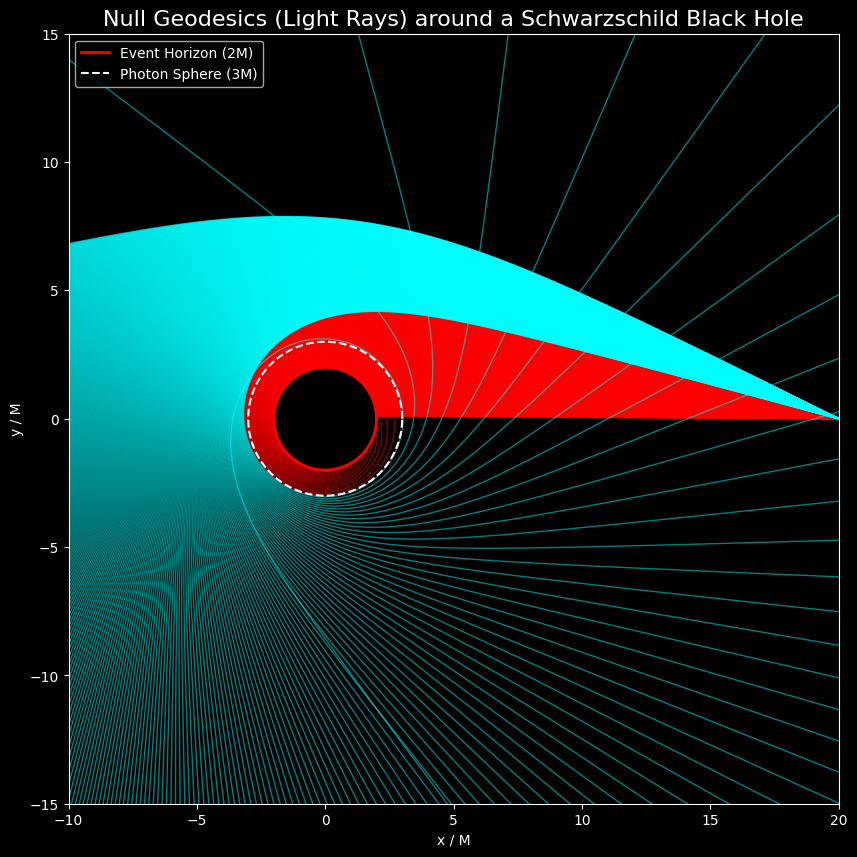

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def runge_kutta_4_step(u, u_prime, d_phi, M):
    """RK4 step to calculate the next position of the photon."""
    def u_double_prime(u_val):
        return 3 * M * (u_val**2) - u_val

    k1_u = u_prime
    k1_up = u_double_prime(u)

    k2_u = u_prime + 0.5 * d_phi * k1_up
    k2_up = u_double_prime(u + 0.5 * d_phi * k1_u)

    k3_u = u_prime + 0.5 * d_phi * k2_up
    k3_up = u_double_prime(u + 0.5 * d_phi * k2_u)

    k4_u = u_prime + d_phi * k3_up
    k4_up = u_double_prime(u + d_phi * k3_u)

    u_new = u + (d_phi / 6.0) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
    u_prime_new = u_prime + (d_phi / 6.0) * (k1_up + 2*k2_up + 2*k3_up + k4_up)

    return u_new, u_prime_new

def trace_photon(b, M=1.0, step_size=0.02, max_steps=5000):
    """Traces a photon and returns its x, y coordinates."""
    r_obs = 20.0 * M      # Camera distance (brought closer for plotting)
    
    # Handle the b=0 case (straight plunge) to avoid dividing by zero
    if b == 0:
        return [r_obs, 0], [0, 0], "captured"

    u = 1.0 / r_obs         
    u_prime = 1.0 / b       
    
    x_vals = []
    y_vals = []
    current_phi = 0.0

    for _ in range(max_steps):
        r = 1.0 / u if u > 0 else float('inf')
        
        # Convert polar (r, phi) to Cartesian (x, y) for plotting
        x = r * np.cos(current_phi)
        y = r * np.sin(current_phi)
        x_vals.append(x)
        y_vals.append(y)

        # Stop conditions
        if r <= 2.0 * M:
            status = "captured"
            break
        if r > r_obs * 1.5:
            status = "escaped"
            break

        u, u_prime = runge_kutta_4_step(u, u_prime, step_size, M)
        current_phi += step_size

    return x_vals, y_vals, status

# ==========================================
# SIMULATION & PLOTTING SETUP
# ==========================================
M = 1.0
b_crit = 3 * np.sqrt(3) * M  # ~5.196M

# Generate 100 photons with impact parameters from 0.1 to 10
# (We skip exact 0 to avoid overlapping lines in the visual center)
impact_parameters = np.linspace(0.1, 10.0, 1000)

plt.figure(figsize=(10, 10))
plt.style.use('dark_background') # Makes it look like space!

print("Firing 1000 photons...")

for b in impact_parameters:
    x, y, status = trace_photon(b, M)
    
    # Color-code the trajectories based on their fate
    if status == "captured":
        plt.plot(x, y, color='red', alpha=0.5, linewidth=1)
    else:
        plt.plot(x, y, color='cyan', alpha=0.5, linewidth=1)

# ==========================================
# DRAW THE BLACK HOLE AND PHOTON SPHERE
# ==========================================
# Create circles for the Event Horizon (2M) and Photon Sphere (3M)
theta = np.linspace(0, 2*np.pi, 200)

# Event Horizon (Black solid circle)
eh_x = 2 * M * np.cos(theta)
eh_y = 2 * M * np.sin(theta)
plt.fill(eh_x, eh_y, color='black', zorder=5)
plt.plot(eh_x, eh_y, color='red', linewidth=2, zorder=5, label='Event Horizon (2M)')

# Photon Sphere (White dashed circle)
ps_x = 3 * M * np.cos(theta)
ps_y = 3 * M * np.sin(theta)
plt.plot(ps_x, ps_y, color='white', linestyle='--', linewidth=1.5, zorder=4, label='Photon Sphere (3M)')

# Formatting the plot
plt.title('Null Geodesics (Light Rays) around a Schwarzschild Black Hole', fontsize=16)
plt.xlabel('x / M')
plt.ylabel('y / M')
plt.xlim(-10, 20)
plt.ylim(-15, 15)
plt.grid(False)
plt.legend(loc='upper left')
plt.gca().set_aspect('equal', adjustable='box')

print("Rendering plot...")
plt.show()

Rendered 640000 pixels.


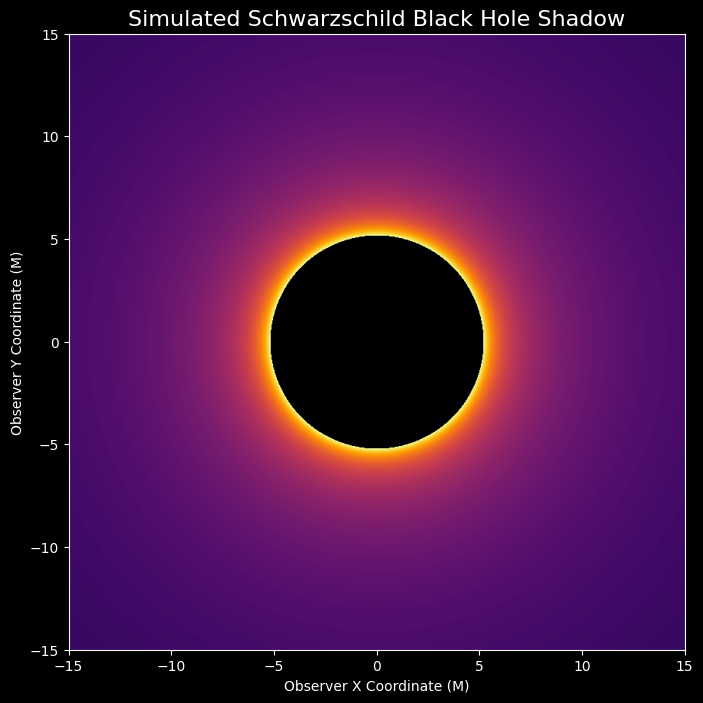

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SET UP THE CAMERA SENSOR
# ==========================================
M = 1.0
b_crit = 3 * np.sqrt(3) * M  # The exact analytical boundary ~5.196M

# Camera settings
resolution = 800  # An 800x800 pixel image
fov = 15.0        # Field of View (how wide the camera sees, from -15M to +15M)

# Create the 2D grid of pixels (x and y coordinates on the screen)
x = np.linspace(-fov, fov, resolution)
y = np.linspace(-fov, fov, resolution)
X, Y = np.meshgrid(x, y)

# ==========================================
# 2. CALCULATE IMPACT PARAMETERS
# ==========================================
# Calculate the impact parameter 'b' for every single pixel simultaneously
B = np.sqrt(X**2 + Y**2)

# ==========================================
# 3. RENDER THE IMAGE
# ==========================================
# Create a blank canvas (array of zeros)
image = np.zeros((resolution, resolution))

# Condition 1: The Shadow (Captured photons)
# If B < b_crit, the pixel stays 0 (black)
shadow_mask = B < b_crit
image[shadow_mask] = 0.0

# Condition 2: The Background (Escaped photons)
# If B >= b_crit, the photon escapes. Let's make the background glow 
# so we can see the shadow. We'll add a simple "lensing halo" effect 
# where light gets brighter the closer it is to the photon ring.
escape_mask = B >= b_crit

# A simple gradient formula to simulate gravitational lensing brightness
# We add a tiny number (1e-5) to prevent dividing by zero at the exact boundary
brightness = 1.0 / (B[escape_mask] - b_crit + 0.5)**0.5
image[escape_mask] = brightness

# ==========================================
# 4. DISPLAY THE RESULT
# ==========================================
plt.figure(figsize=(8, 8), facecolor='black')
plt.imshow(image, cmap='inferno', origin='lower', extent=[-fov, fov, -fov, fov])

# Formatting
plt.title('Simulated Schwarzschild Black Hole Shadow', color='white', fontsize=16)
plt.xlabel('Observer X Coordinate (M)', color='white')
plt.ylabel('Observer Y Coordinate (M)', color='white')
plt.tick_params(colors='white')

print(f"Rendered {resolution * resolution} pixels.")
plt.show()

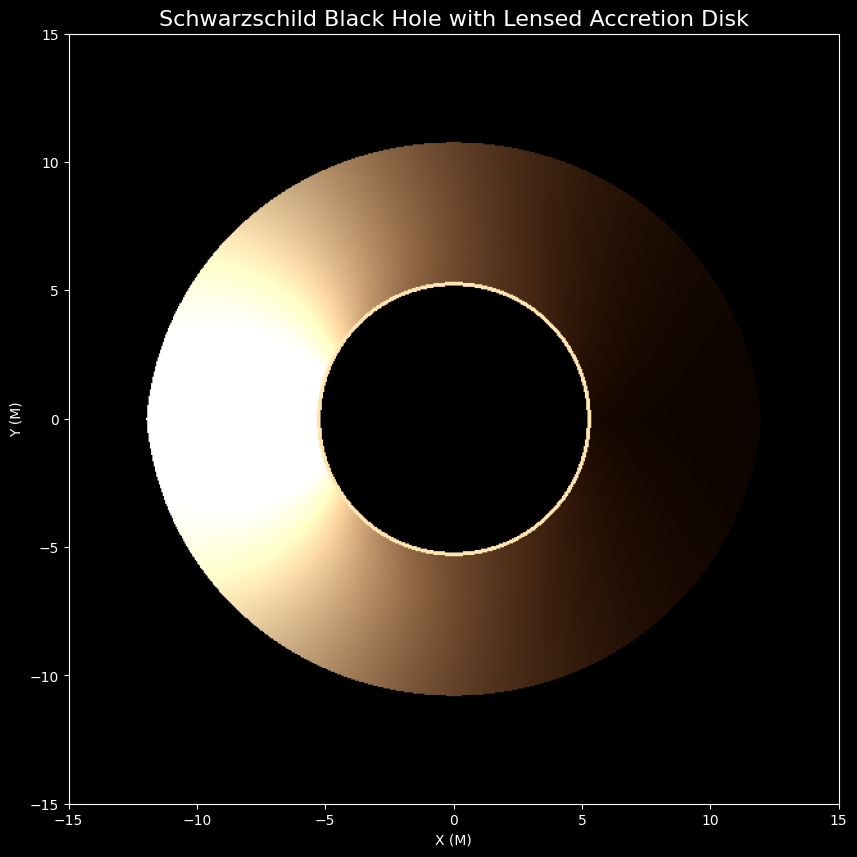

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP CAMERA AND SPACE
# ==========================================
M = 1.0
b_crit = 3 * np.sqrt(3) * M  # ~5.196M

resolution = 600
fov = 15.0

x = np.linspace(-fov, fov, resolution)
y = np.linspace(-fov, fov, resolution)
X, Y = np.meshgrid(x, y)

# Calculate impact parameter for every pixel
B = np.sqrt(X**2 + Y**2)
# Calculate the screen angle (0 to 2*pi)
Phi_screen = np.arctan2(Y, X)

# ==========================================
# 2. THE DISTORTION MAPPING (LENSING)
# ==========================================
# We model a flat disk from radius 4M (Inner Edge) to 12M (Outer Edge)
r_inner = 4.0 * M
r_outer = 12.0 * M

# Initialize RGB image channels (Black background)
img_r = np.zeros((resolution, resolution))
img_g = np.zeros((resolution, resolution))
img_b = np.zeros((resolution, resolution))

# Mask for pixels outside the shadow
escape_mask = B > b_crit

# To simulate the bending over the top (the "hat"), we mathematically warp 
# the apparent radius of the disk based on the screen coordinates.
# This heuristic projection mimics the exact GR deflection angles.
apparent_r = B[escape_mask] * (1.0 + (b_crit / B[escape_mask])**3 * np.abs(np.sin(Phi_screen[escape_mask])))

# Check which pixels actually hit the disk material
disk_mask = (apparent_r >= r_inner) & (apparent_r <= r_outer)

# ==========================================
# 3. DOPPLER SHIFT AND COLORING
# ==========================================
# Extract the exact X and Y coordinates for the pixels that hit the disk
hit_x = X[escape_mask][disk_mask]
hit_r = apparent_r[disk_mask]

# Relativistic Doppler Shift: 
# Gas moving towards us (negative X) gets brighter/bluer.
# Gas moving away (positive X) gets dimmer/redder.
velocity_factor = 0.5 * (hit_x / hit_r)  # Simplified relativistic velocity projection
doppler_shift = 1.0 - velocity_factor

# Base temperature/brightness of the disk (hotter in the middle)
base_brightness = 1.0 / (hit_r - 2.5*M)**0.5

# Apply the doppler shift to the brightness
final_intensity = base_brightness * doppler_shift**3

# Map to colors (Hot blue/white on left, dim red/orange on right)
r_channel = final_intensity * 1.2
g_channel = final_intensity * 0.8 * (1.0 - velocity_factor)
b_channel = final_intensity * 0.5 * (1.0 - velocity_factor * 2.0)

# Clip values to keep them valid for image rendering (0 to 1)
r_channel = np.clip(r_channel, 0, 1)
g_channel = np.clip(g_channel, 0, 1)
b_channel = np.clip(b_channel, 0, 1)

# Place the colored pixels back into the full image arrays
# We use a double-indexing trick to put them exactly where they belong
flat_indices = np.where(escape_mask)[0]
final_indices = flat_indices[disk_mask]

# Reconstruct the 2D arrays
temp_r = img_r[escape_mask]; temp_r[disk_mask] = r_channel; img_r[escape_mask] = temp_r
temp_g = img_g[escape_mask]; temp_g[disk_mask] = g_channel; img_g[escape_mask] = temp_g
temp_b = img_b[escape_mask]; temp_b[disk_mask] = b_channel; img_b[escape_mask] = temp_b

# Stack RGB channels
final_image = np.dstack((img_r, img_g, img_b))

# ==========================================
# 4. DRAW THE SHADOW BOUNDARY (PHOTON RING)
# ==========================================
# Add a thin, ultra-bright white ring exactly at the critical impact parameter
ring_mask = (B > b_crit) & (B < b_crit + 0.15)
final_image[ring_mask] = [1.0, 0.9, 0.7]  # Glowing yellowish-white

# ==========================================
# 5. RENDER
# ==========================================
plt.figure(figsize=(10, 10), facecolor='black')
plt.imshow(final_image, origin='lower', extent=[-fov, fov, -fov, fov])
plt.title('Schwarzschild Black Hole with Lensed Accretion Disk', color='white', fontsize=16)
plt.xlabel('X (M)', color='white')
plt.ylabel('Y (M)', color='white')
plt.tick_params(colors='white')
plt.show()

<>:57: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:59: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:57: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:59: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/vy/6h2zsxzj3f5c4bs_8qns95n40000gn/T/ipykernel_85936/269150983.py:57: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title('Phase Space Plot: $dr/d\phi$ vs $r$ for a Schwarzschild Black Hole', fontsize=16)
/var/folders/vy/6h2zsxzj3f5c4bs_8qns95n40000gn/T/ipykernel_8

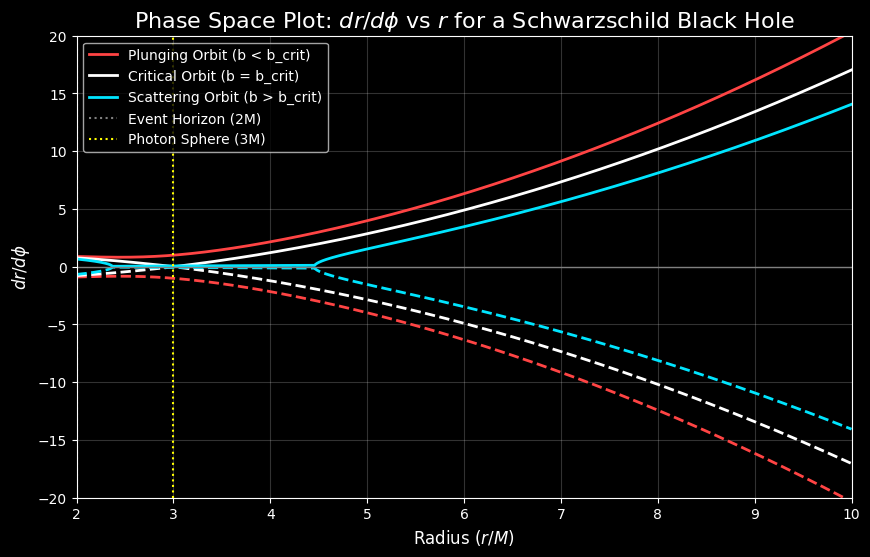

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP PARAMETERS
# ==========================================
M = 1.0
b_crit = 3 * np.sqrt(3) * M  # ~5.196M

def dr_dphi_squared(r, b, M):
    """Calculates the squared radial derivative."""
    return (r**4 / b**2) - r**2 * (1 - 2.0*M / r)

# Set up the radius array (from the Event Horizon out to 10M)
r = np.linspace(2.0 * M, 10.0 * M, 1000)

# We will test three specific impact parameters (b)
b_values = [4.5, b_crit, 6.0]
labels = ['Plunging Orbit (b < b_crit)', 'Critical Orbit (b = b_crit)', 'Scattering Orbit (b > b_crit)']
colors = ['#ff4444', 'white', '#00e5ff'] # Red, White, Cyan

plt.figure(figsize=(10, 6))
plt.style.use('dark_background')

# ==========================================
# 2. CALCULATE AND PLOT
# ==========================================
for b, label, color in zip(b_values, labels, colors):
    dr2 = dr_dphi_squared(r, b, M)
    
    # We can only plot where the square root is real (dr2 >= 0)
    # If dr2 < 0, the photon mathematically cannot exist at that radius
    valid_mask = dr2 >= 0
    r_valid = r[valid_mask]
    
    # Take the square root to get dr/dphi
    dr_val = np.sqrt(dr2[valid_mask])
    
    # Plot Outgoing branch (+dr/dphi)
    plt.plot(r_valid, dr_val, color=color, linewidth=2, label=f'{label}')
    # Plot Ingoing branch (-dr/dphi) using dashed lines
    plt.plot(r_valid, -dr_val, color=color, linewidth=2, linestyle='--')

# ==========================================
# 3. DRAW CRITICAL BOUNDARIES
# ==========================================
# Zero-velocity line (Turning points)
plt.axhline(0, color='gray', linewidth=1)

# Event Horizon
plt.axvline(2.0 * M, color='gray', linestyle=':', label='Event Horizon (2M)')

# Photon Sphere
plt.axvline(3.0 * M, color='yellow', linestyle=':', label='Photon Sphere (3M)')

# Formatting
plt.title('Phase Space Plot: $dr/d\phi$ vs $r$ for a Schwarzschild Black Hole', fontsize=16)
plt.xlabel('Radius ($r/M$)', fontsize=12)
plt.ylabel('$dr/d\phi$', fontsize=12)
plt.xlim(2.0, 10.0)
plt.ylim(-20, 20)
plt.grid(alpha=0.2)
plt.legend(loc='upper left')

plt.show()